# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

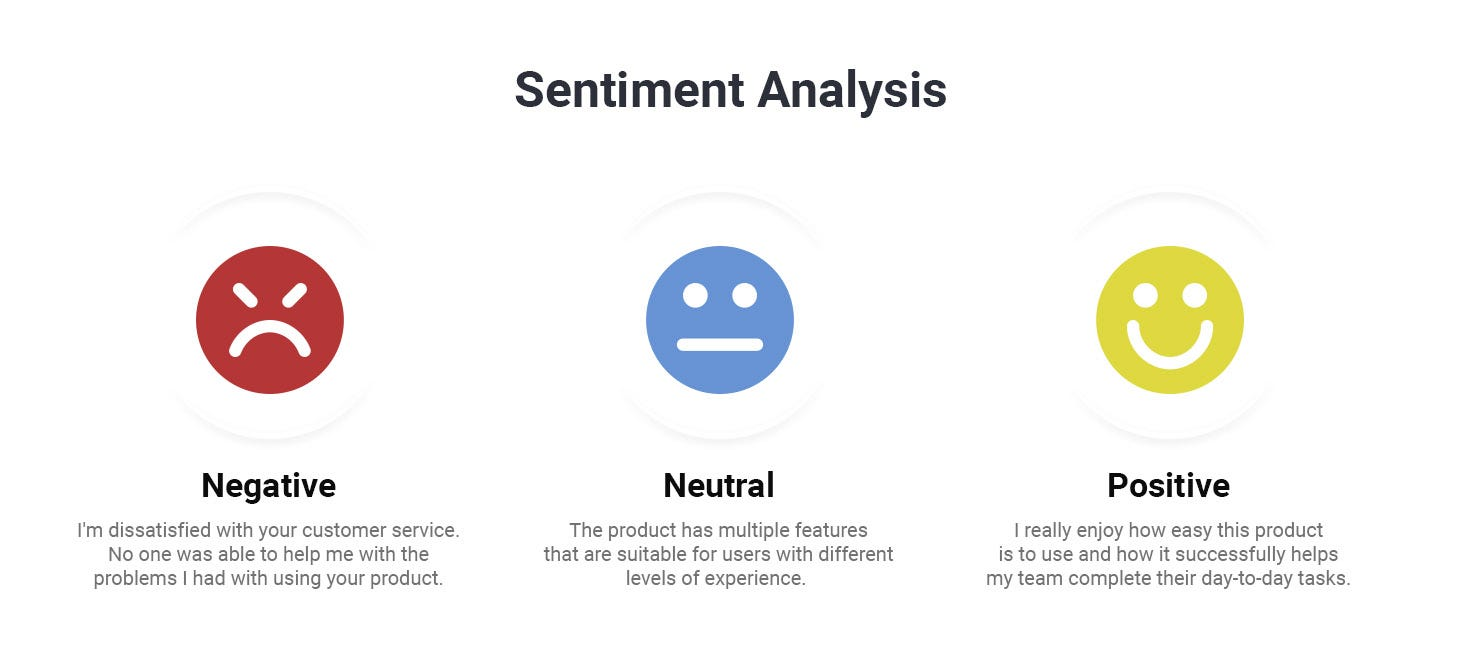

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

FileNotFoundError: [Errno 2] No such file or directory: '/content/DisneylandReviews.csv'

In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JoudA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JoudA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\JoudA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
file_path = r'C:\Users\JoudA\NLP\NLP_Lab4\Amazon_Unlocked_Mobile.csv'

data = pd.read_csv(file_path)

print("Original dataset shape:", data.shape)
display(data.head())

Original dataset shape: (413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [3]:
# Check missing values
print("\nMissing values:")
display(data[['Reviews', 'Rating']].isna().sum())

# Keep rows containing both a review and a rating
data = data.dropna(subset=['Reviews', 'Rating']).copy()

# Ensure Rating is numeric
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')
data = data.dropna(subset=['Rating'])

# Keep only valid ratings from 1 to 5
data = data[data['Rating'].between(1, 5)].copy()



Missing values:


Reviews    70
Rating      0
dtype: int64

In [4]:
# Convert ratings into sentiment classes
def rating_to_sentiment(rating):
    if rating > 3:
        return 'positive'
    elif rating < 3:
        return 'negative'
    else:
        return 'neutral'


data['Sentiment'] = data['Rating'].apply(rating_to_sentiment)

print("\nSentiment distribution:")
display(data['Sentiment'].value_counts())



Sentiment distribution:


Sentiment
positive    284948
negative     97059
neutral      31763
Name: count, dtype: int64

In [5]:
# Prepare preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    # Step 1: Convert text to lowercase
    text = str(text).lower()

    # Step 2: Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Step 3: Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 4: Tokenize the text
    tokens = text.split()

    # Step 5: Remove stopwords and lemmatize the remaining words
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(tokens)

In [6]:
# Apply preprocessing
data['Cleaned_Review'] = data['Reviews'].apply(preprocess_text)

# Remove reviews that became empty after preprocessing
data = data[data['Cleaned_Review'].str.strip() != ''].copy()

print("\nDataset shape after preprocessing:", data.shape)

display(
    data[['Reviews', 'Cleaned_Review', 'Rating', 'Sentiment']].head()
)


Dataset shape after preprocessing: (412506, 8)


,Reviews,Cleaned_Review,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone u used hard phone ...,5,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,4,positive
2,Very pleased,pleased,5,positive
3,It works good but it goes slow sometimes but i...,work good go slow sometimes good phone love,4,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,4,positive


In [7]:
X = data['Cleaned_Review']
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
display(y_train.value_counts())

print("\nTesting class distribution:")
display(y_test.value_counts())

Training samples: 330004
Testing samples: 82502

Training class distribution:


Sentiment
positive    227112
negative     77521
neutral      25371
Name: count, dtype: int64


Testing class distribution:


Sentiment
positive    56778
negative    19381
neutral      6343
Name: count, dtype: int64

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Fit only on training data to prevent data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using the fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (330004, 10000)
Testing TF-IDF shape: (82502, 10000)


In [9]:
nb_classifier = MultinomialNB(alpha=1.0)

nb_classifier.fit(X_train_tfidf, y_train)

y_pred = nb_classifier.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    )
)

Accuracy: 0.8480

Classification Report:
              precision    recall  f1-score   support

    negative     0.8020    0.7756    0.7886     19381
     neutral     0.3706    0.0940    0.1499      6343
    positive     0.8742    0.9570    0.9137     56778

    accuracy                         0.8480     82502
   macro avg     0.6823    0.6088    0.6174     82502
weighted avg     0.8185    0.8480    0.8256     82502



Confusion Matrix:
[[15031   299  4051]
 [ 1980   596  3767]
 [ 1730   713 54335]]


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,15031,299,4051
Actual neutral,1980,596,3767
Actual positive,1730,713,54335


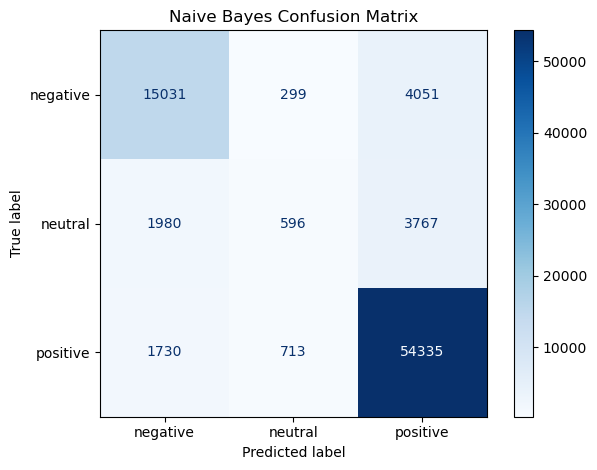

In [11]:
class_labels = ['negative', 'neutral', 'positive']

confusion_matrix_result = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

print("Confusion Matrix:")
print(confusion_matrix_result)

display(
    pd.DataFrame(
        confusion_matrix_result,
        index=[f'Actual {label}' for label in class_labels],
        columns=[f'Predicted {label}' for label in class_labels]
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_result,
    display_labels=class_labels
).plot(
    cmap='Blues',
    values_format='d'
)

plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()